# EDA — IBM Telco Customer Churn

Цель ноутбука: провести первичный анализ данных для задачи прогнозирования оттока клиентов телеком-компании.

Этот ноутбук **не является финальным training pipeline**. Он нужен для исследования данных, поиска проблем в данных и формулирования инсайтов для `README.md`.

Важно: финальный preprocessing, feature engineering и обучение должны быть реализованы внутри `Pipeline` в `scripts/train.py`.


## 1. Imports and settings

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)


## 2. Load data

Файл должен лежать по относительному пути:

```text
data/WA_Fn-UseC_-Telco-Customer-Churn.csv
```


In [2]:
DATA_PATH = Path('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

if not DATA_PATH.exists():
    DATA_PATH = Path('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

assert DATA_PATH.exists(), f'File not found: {DATA_PATH}'

df = pd.read_csv(DATA_PATH)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Basic dataset overview

In [23]:
df.shape

(7043, 22)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Notes about column types

- `TotalCharges` должен быть числовым, но обычно загружается как `object`, потому что содержит пустые строки.
- `customerID` — идентификатор клиента, его нельзя использовать как ML-признак.
- `Churn` — целевая переменная: `Yes` / `No`.


## 4. Target distribution: Churn

In [8]:
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True).mul(100).round(2)

pd.DataFrame({
    'count': churn_counts,
    'percent': churn_rate
})


,count,percent
Churn,,
No,5174,73.46
Yes,1869,26.54


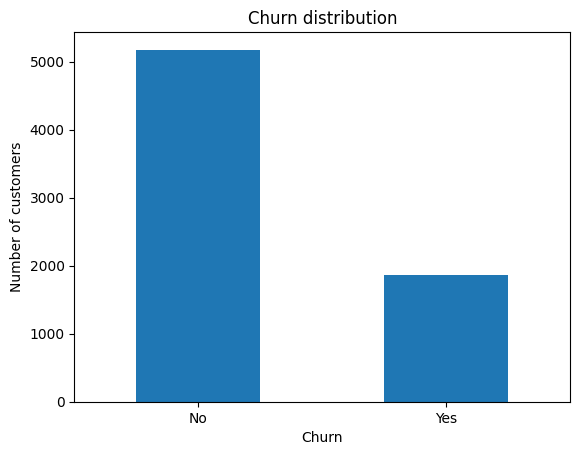

In [9]:
ax = churn_counts.plot(kind='bar')
ax.set_title('Churn distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of customers')
plt.xticks(rotation=0)
plt.show()


### Note

Accuracy будет плохой основной метрикой, потому что классы несбалансированы: большинство клиентов не ушли в отток. Поэтому в финальном обучении нужно использовать recall, precision, F1, ROC-AUC и precision-recall анализ.


## 5. Missing values analysis

In [10]:
explicit_missing = df.isna().sum().sort_values(ascending=False)
explicit_missing[explicit_missing > 0]


Series([], dtype: int64)

### Implicit missing values

Проверим, что `TotalCharges` содержит пустые строки.


In [11]:
object_cols = df.select_dtypes(include='object').columns

implicit_missing = {}
for col in object_cols:
    implicit_missing[col] = df[col].astype(str).str.strip().eq('').sum()

implicit_missing = pd.Series(implicit_missing).sort_values(ascending=False)
implicit_missing[implicit_missing > 0]


TotalCharges    11
dtype: int64

In [12]:
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('NaN after converting TotalCharges:', df['TotalCharges_numeric'].isna().sum())
df.loc[df['TotalCharges_numeric'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].head(20)


NaN after converting TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Note

В финальном проекте `TotalCharges` нужно конвертировать через `pd.to_numeric(..., errors='coerce')`, а появившиеся `NaN` импутировать внутри `Pipeline`, не до split.


## 6. Numeric features distribution

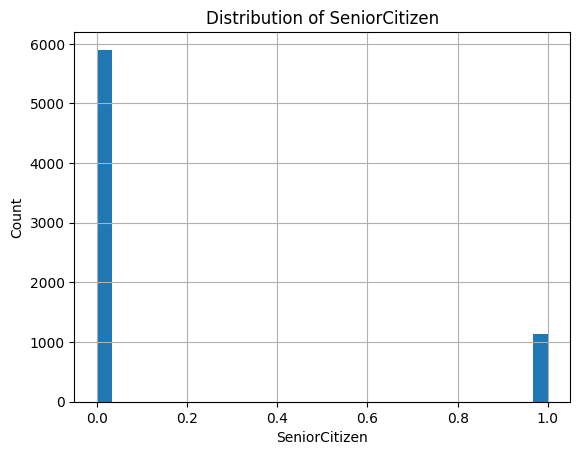

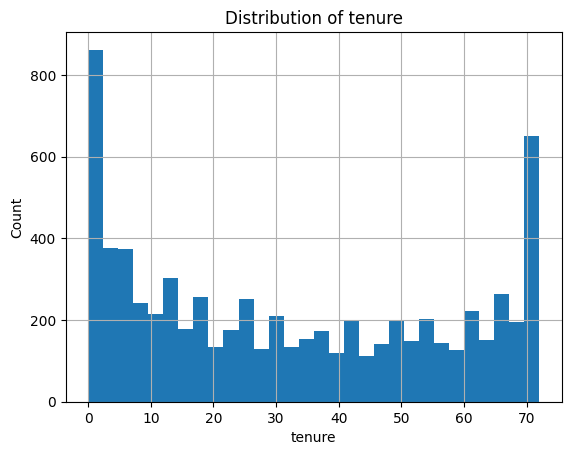

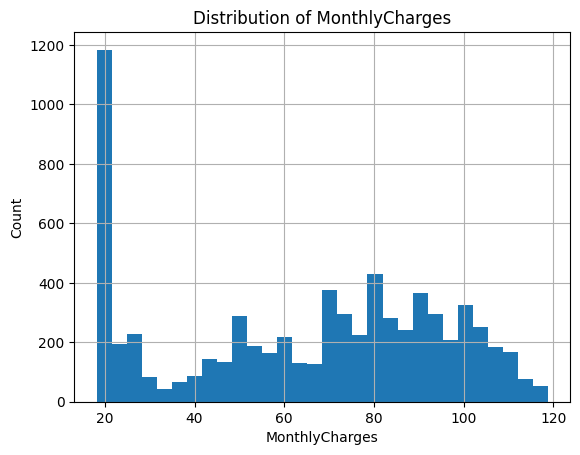

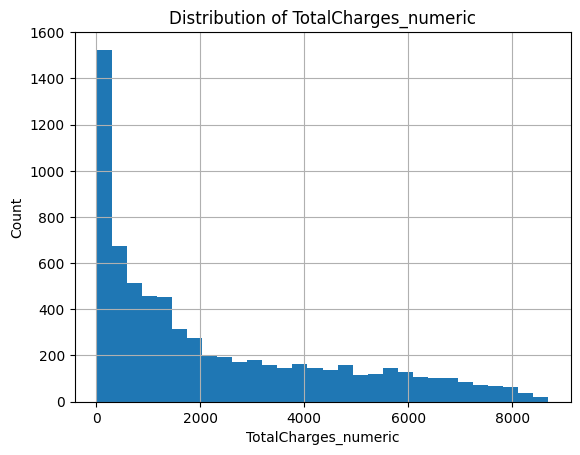

In [13]:
numeric_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges_numeric']

for col in numeric_cols:
    ax = df[col].hist(bins=30)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    plt.show()


### Note

* Клиенты с небольшим сроком пользования услугами (`tenure`) чаще уходят.
* Долгосрочные клиенты, как правило, более лояльны.
* Клиенты с более высокими ежемесячными платежами (`MonthlyCharges`) уходят чаще.


## 7. Categorical features overview

In [14]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object' and col not in ['customerID', 'Churn', 'TotalCharges']]
cat_cols


['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [16]:
for col in cat_cols:
    print(f'{col}')
    display(df[col].value_counts(dropna=False))


gender


gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner


Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents


...

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

PaperlessBilling


PaperlessBilling
Yes    4171
No     2872
Name: count, dtype: int64

PaymentMethod


PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

## 8. Churn by key categorical columns

Нужно сделать cross-tab минимум по трём колонкам:

- `Contract`
- `PaymentMethod`
- `InternetService`


In [17]:
def churn_crosstab(dataframe, col):
    table = pd.crosstab(dataframe[col], dataframe['Churn'], margins=True)
    rates = pd.crosstab(dataframe[col], dataframe['Churn'], normalize='index').mul(100).round(2)
    result = table.join(rates, rsuffix='_percent')
    return result

for col in ['Contract', 'PaymentMethod', 'InternetService']:
    print(f'Churn by {col}')
    display(churn_crosstab(df, col))


Churn by Contract


Churn,No,Yes,All,No_percent,Yes_percent
Contract,,,,,
Month-to-month,2220,1655,3875,57.29,42.71
One year,1307,166,1473,88.73,11.27
Two year,1647,48,1695,97.17,2.83
All,5174,1869,7043,NaN,NaN


Churn by PaymentMethod


Churn,No,Yes,All,No_percent,Yes_percent
PaymentMethod,,,,,
Bank transfer (automatic),1286,258,1544,83.29,16.71
Credit card (automatic),1290,232,1522,84.76,15.24
Electronic check,1294,1071,2365,54.71,45.29
Mailed check,1304,308,1612,80.89,19.11
All,5174,1869,7043,NaN,NaN


Churn by InternetService


Churn,No,Yes,All,No_percent,Yes_percent
InternetService,,,,,
DSL,1962,459,2421,81.04,18.96
Fiber optic,1799,1297,3096,58.11,41.89
No,1413,113,1526,92.60,7.40
All,5174,1869,7043,NaN,NaN


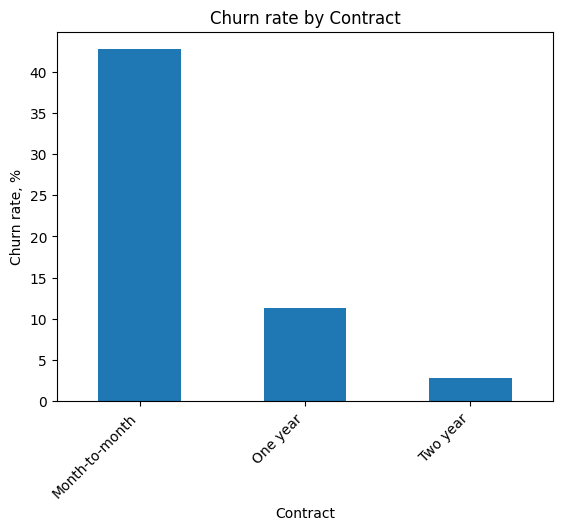

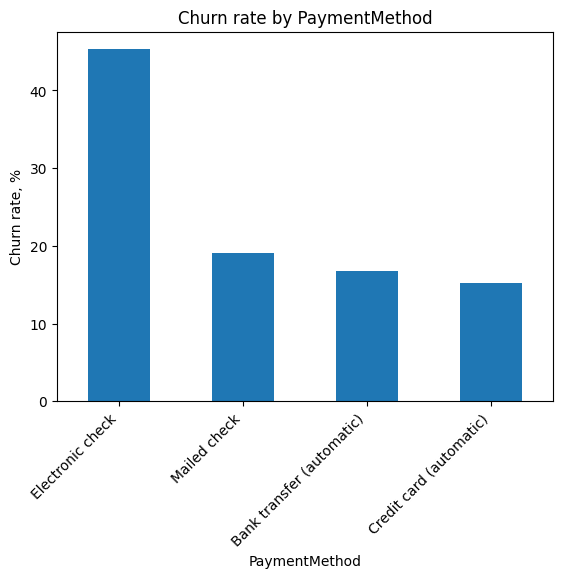

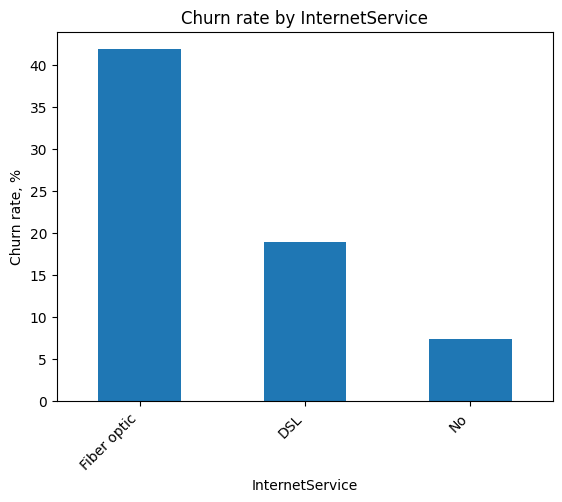

In [18]:
for col in ['Contract', 'PaymentMethod', 'InternetService']:
    churn_by_col = pd.crosstab(df[col], df['Churn'], normalize='index')['Yes'].sort_values(ascending=False) * 100
    ax = churn_by_col.plot(kind='bar')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn rate, %')
    plt.xticks(rotation=45, ha='right')
    plt.show()


## 9. Churn by numeric columns

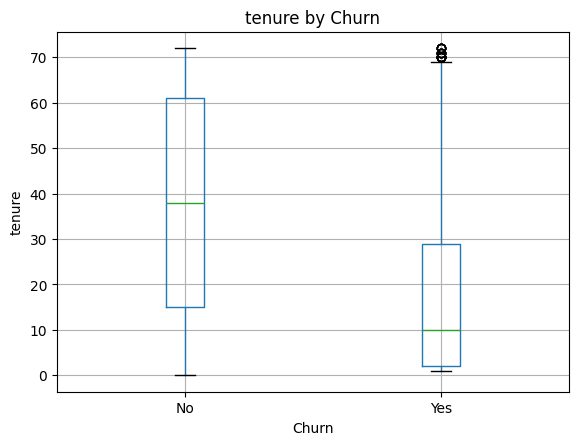

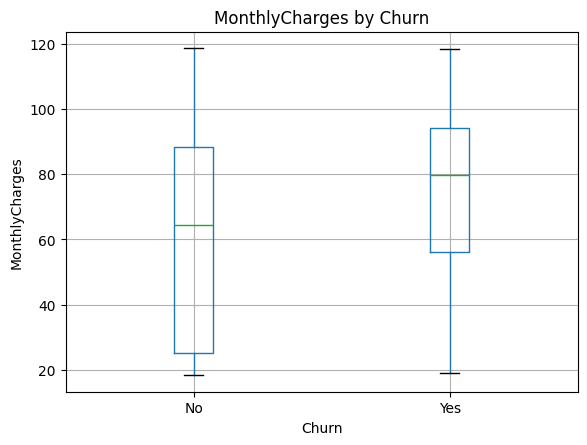

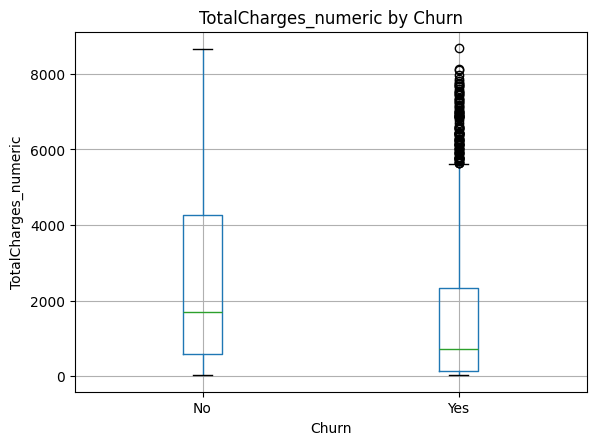

In [19]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges_numeric']:
    ax = df.boxplot(column=col, by='Churn')
    ax.set_title(f'{col} by Churn')
    ax.set_xlabel('Churn')
    ax.set_ylabel(col)
    plt.suptitle('')
    plt.show()


## 10. Draft feature engineering ideas

Эти признаки здесь можно исследовать, но в финальном решении они должны быть реализованы внутри `Pipeline`.

- `tenure_bucket` отражает этапы жизненного цикла клиента.
- `charges_per_month_of_tenure` может выявлять клиентов с необычно высокими расходами.
- `n_services` показывает уровень вовлечённости клиента в услуги компании.

In [20]:
eda_df = df.copy()

eda_df['tenure_bucket'] = pd.cut(
    eda_df['tenure'],
    bins=[-1, 12, 24, 48, np.inf],
    labels=['0-12', '13-24', '25-48', '49+']
)

eda_df['charges_per_month_of_tenure'] = (
    eda_df['TotalCharges_numeric'] / eda_df['tenure'].clip(lower=1)
)

service_cols = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
    'StreamingMovies'
]

eda_df['n_services'] = eda_df[service_cols].apply(
    lambda row: sum(str(value) not in ['No', 'No internet service'] for value in row),
    axis=1
)

eda_df[['customerID', 'tenure', 'tenure_bucket', 'TotalCharges_numeric', 'charges_per_month_of_tenure', 'n_services']].head()


,customerID,tenure,tenure_bucket,TotalCharges_numeric,charges_per_month_of_tenure,n_services
0,7590-VHVEG,1,0-12,29.85,29.850000,3
1,5575-GNVDE,34,25-48,1889.50,55.573529,4
2,3668-QPYBK,2,0-12,108.15,54.075000,4
3,7795-CFOCW,45,25-48,1840.75,40.905556,5
4,9237-HQITU,2,0-12,151.65,75.825000,2


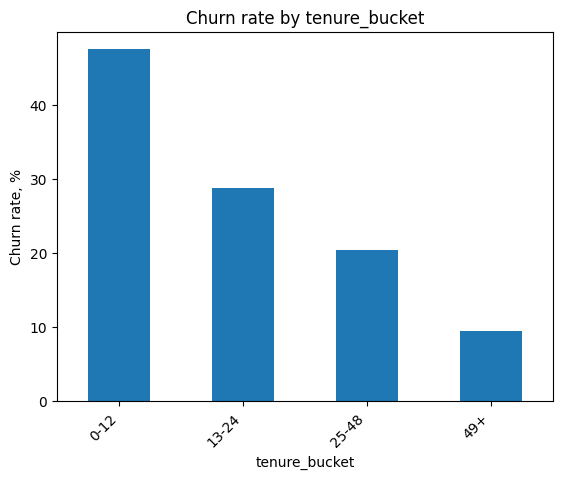

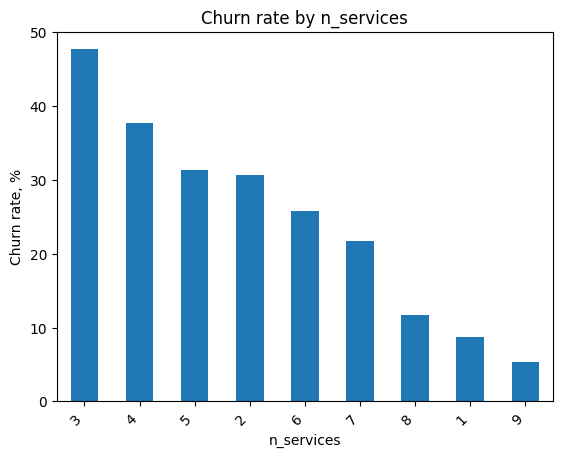

In [21]:
for col in ['tenure_bucket', 'n_services']:
    churn_by_col = pd.crosstab(eda_df[col], eda_df['Churn'], normalize='index')['Yes'].sort_values(ascending=False) * 100
    ax = churn_by_col.plot(kind='bar')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Churn rate, %')
    plt.xticks(rotation=45, ha='right')
    plt.show()


## 11. Initial insights
 
1. Датасет несбалансирован (~73% клиентов не уходят).
2. Клиенты с помесячным контрактом имеют самый высокий уровень оттока.
3. Клиенты с небольшим сроком пользования услугами чаще уходят.
4. Пользователи electronic check имеют повышенный риск оттока.
5. Клиенты с Fiber optic уходят чаще, чем пользователи DSL.
6. Клиенты с более высокими ежемесячными платежами чаще уходят.
7. `TotalCharges` содержит скрытые пропуски и должен быть обработан аккуратно внутри Pipeline.
8. Добавить новые признаки
9. Удалить из данных для модели `customerID`, `Churn`
10. Разделить колонки на числовые и на категориальные
